In [1]:
%run shared_imports.py

In [2]:
engine = make_engine("settings.toml")
session = Session(engine)

In [8]:
query = session.query(Feedback).join(Round).filter(
        Feedback.key_name=='ore_mined',
        Round.start_datetime >= datetime(2024, 7, 1))

df = pd.read_sql_query(query.statement, session.connection())

In [9]:
def json_to_series(text):
    keys, values = zip(*[(k, v) for k, v in text['data'].items()])
    return pd.Series(values, index=keys)
df = pd.concat([df, df['json'].apply(json_to_series)], axis=1)

In [19]:
ore_names = [x for x in df.columns if x.startswith('/')]

In [11]:
df['month'] = df.datetime.dt.month
df['day'] = df.datetime.dt.day
df['year'] = df.datetime.dt.year

In [20]:
data = dict()
for pref in ore_names:
    datum = df.groupby(['month', 'year'], as_index=False)[pref].mean(numeric_only=True)
    datum['dt']= pd.to_datetime(datum.year.astype(str) + datum.month.astype(str), format='%Y%m')
    data[pref] = datum

# datum = df.groupby(['month', 'year'], as_index=False)["high"].mean(numeric_only=True)
# datum['dt']= pd.to_datetime(datum.year.astype(str) + datum.month.astype(str), format='%Y%m')

In [21]:
data

{'/obj/item/stack/ore/plasma':    month  year  /obj/item/stack/ore/plasma         dt
 0      1  2024                  650.954545 2024-01-01
 1      2  2024                  598.202857 2024-02-01
 2      3  2024                  592.518817 2024-03-01
 3      4  2024                  638.145604 2024-04-01
 4      5  2024                  647.740458 2024-05-01
 5      6  2024                  705.848901 2024-06-01
 6      7  2024                  675.706806 2024-07-01
 7      8  2024                  687.152815 2024-08-01
 8      9  2024                  573.145038 2024-09-01
 9     12  2023                  119.000000 2023-12-01,
 '/obj/item/stack/ore/diamond':    month  year  /obj/item/stack/ore/diamond         dt
 0      1  2024                    37.250000 2024-01-01
 1      2  2024                    34.815789 2024-02-01
 2      3  2024                    33.720222 2024-03-01
 3      4  2024                    34.475783 2024-04-01
 4      5  2024                    35.545455 2024-05-

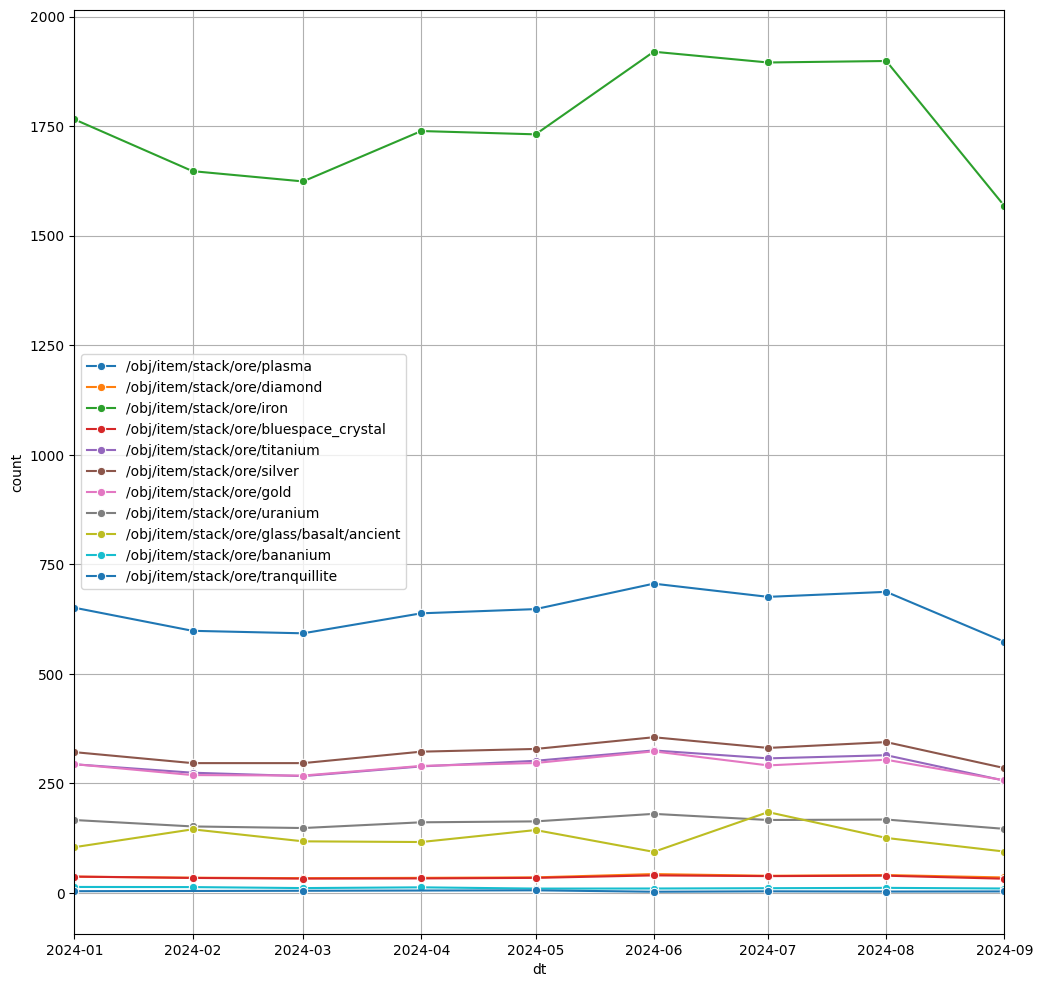

In [24]:
fig, ax = plt.subplots()
fig.set_size_inches(12, 12)
for pref, datum in data.items():
    sns.lineplot(data=datum, x='dt', y=pref, marker='o', label=pref)

ax.set(ylabel='count')
plt.grid()
plt.xlim(date(2024, 1, 1), date(2024, 9, 1))
plt.savefig('cap_avg.png')